# Imports and Libraries

## Installs

Dataset and code for downloading found:
https://huggingface.co/docs/datasets/v1.13.2/load_hub.html

In [42]:
# Commented out to stop multiple runs when running entire notebook
#%pip install -U datasets

## Imports

`load_dataset` - For downloading sst2 dataset

`DatasetDict` - For creating project dataset splits

`pd` - For usage of DataFrame type

`AutoTokenizer` - For tokenisation of datasets required for transformer based models

`np` - Used in evaluation metrics for finding highest model output score

`accuracy_score` - Used to calculate overall accuracy of model

`precision_recall_fscore_support` - Used to calculate precision, recall, F1 and support of model

`AutoModelForSequenceClassification` - Used to load tansformer model for classification tasks

`DataCollatorWithPadding` - Used for padding training batches

`TrainingArguments` - Sets training arguments for model during training

`Trainer` - Joins together model arguments, model, datasets, collator, metrics, etc. to train model

`plt` - Used to plot model results

`random` - Used when creating noise 

`` - 

`` - 



In [43]:
from datasets import load_dataset, DatasetDict
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import random

# Defining which Model

In [44]:
# Defining which model.
model_name = "distilbert-base-uncased"

# Dataset

`dataframe_check` function:

- Takes:
  - `dataframe`: a dataFrame containing training, validation and testing data


This function performs a couple of manual checks on the dataset for inspection by the user. For example, printing the first few values and checking the balance

In [45]:
def dataframe_check(dataframe):
    # Check first couple values
    print("Dataframe head:")
    print(dataframe.head())
    print("\n-----------------------------------")
    print("\nBalance of dataset")
    print(dataframe["label"].value_counts())
    print(dataframe["label"].value_counts(normalize=True))

Load the sst2 dataset.

In [46]:
sst2 = load_dataset("glue", "sst2")

Convert to a dataframe and call the `dataframe_check` function to print some infomation about the training data

In [47]:
train_df = pd.DataFrame(sst2["train"])
dataframe_check(train_df)

Dataframe head:
                                            sentence  label  idx
0       hide new secretions from the parental units       0    0
1               contains no wit , only labored gags       0    1
2  that loves its characters and communicates som...      1    2
3  remains utterly satisfied to remain the same t...      0    3
4  on the worst revenge-of-the-nerds clichés the ...      0    4

-----------------------------------

Balance of dataset
label
1    37569
0    29780
Name: count, dtype: int64
label
1    0.557826
0    0.442174
Name: proportion, dtype: float64


# Create datset splits

The SST-2 has hidden labels for test data so only training and validation data will be taken into account. Training data will be split into training and testing.

In [48]:
train_test_split = sst2["train"].train_test_split(
    test_size = 0.2, # 20% used for testing
    seed = 42, # Seed for database split
    stratify_by_column = "label" # Keep label balance after split
)

# Remake DatasetDict with new split, since original had no test data labels
sst2_split = DatasetDict({
    "train": train_test_split["train"],
    "validation": sst2["validation"],
    "test": train_test_split["test"]
})

# Tokenisation of data

In [49]:
# Create the tokenizer for DistilBERT
tokenizer = AutoTokenizer.from_pretrained(model_name)

`tokenize` function:

- Takes:
  - `batch`: dictionary batch of rows from dataset

- Returns:
  - `tokenizer`: BertTokenizer containing numerical token IDs


Takes a batch of dataset rows and converts the sentences into token IDs. Also removed sentences longer than 128 tokens.

In [50]:
def tokenize(batch):
    return tokenizer(
        batch["sentence"], # select sentence text from dataset
        truncation=True, # cuts off text if it is too long
        max_length=128 # limits each sentence to 128 tokens. enough for SST2 due to short sentences
    )

In [51]:
# Applies tokenize function to each sentence
tokenized_sst2 = sst2_split.map(tokenize, batched=True)

# Remove columns no longer needed for training such as sentences, index.
tokenized_sst2 = tokenized_sst2.remove_columns(["sentence", "idx"])
# Rename column label to labels for compatibility
tokenized_sst2 = tokenized_sst2.rename_column("label", "labels")
# Return Pytorch tensor for tokenized_sst2
tokenized_sst2.set_format("torch")

# Setup Evaluation Metrics

`evaluation_metrics` function:

- Takes:
  - `eval_prediction`: Models predictions and correct labels

- Returns:
  - `Dictionary`: Dictionary of evaluation results including precision, recall, f1 and accuracy


This function takes models predictions and correct labels and returns a series of evaluation metrics about those predictions including accuracy, recall, f1 and precision

In [52]:
def compute_metrics(eval_prediction):
    # Split incoming prediction into model prediction and correct labels
    raw_data, labels = eval_prediction

    # Convert output to class prediciton
    predictions = np.argmax(raw_data, axis=-1)

    # Compare predictions against labels
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions,
        average="binary" # binary as sst2 has binary labels 1 or 0.
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

# Loading Model and Data Collator

In [53]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2 # Number of outputs (1, 0)
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [54]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Defining Training Arguments

https://huggingface.co/docs/transformers/v4.15.0/en/main_classes/trainer#transformers.TrainingArguments

In [55]:
training_args = TrainingArguments(
    output_dir="./distilbert_sst2_baseline", # Output for trianing files
    eval_strategy="epoch", # Evaluation after each epoch
    save_strategy="epoch", # Save Model after each epoch
    learning_rate=2e-5, 
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True, # Keeps best saved model
    metric_for_best_model="f1", # How it decides which model is best
    greater_is_better=True, # Dictates higher F1 is better
    report_to="none" # Stop hugging face logging data
)

# Creating Trainer and training the model

In [56]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_sst2["train"],
    eval_dataset=tokenized_sst2["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [57]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.410368,0.541591,0.921296,0.896396,0.908676,0.908257
2,0.302469,0.729896,0.911565,0.905405,0.908475,0.907110
3,0.194272,0.910882,0.890830,0.918919,0.904656,0.901376


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=10104, training_loss=0.325030349118315, metrics={'train_runtime': 1043.6209, 'train_samples_per_second': 154.881, 'train_steps_per_second': 9.682, 'total_flos': 1468512366018600.0, 'train_loss': 0.325030349118315, 'epoch': 3.0})

# Training Graphs

In [58]:
# Convert trianing log history into DataFrame
history = pd.DataFrame(trainer.state.log_history)

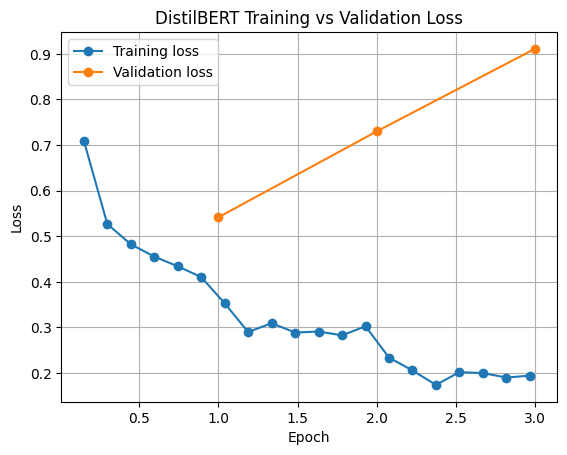

In [59]:
train_loss = history.dropna(subset=["loss"]) # DataFrame with only loss
eval_loss = history.dropna(subset=["eval_loss"]) # DataFrame with only eval_loss

# Plot the 2 DataFrames
plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="Training loss")
plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", label="Validation loss")

# Label the Axis and provide Title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training vs Validation Loss")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

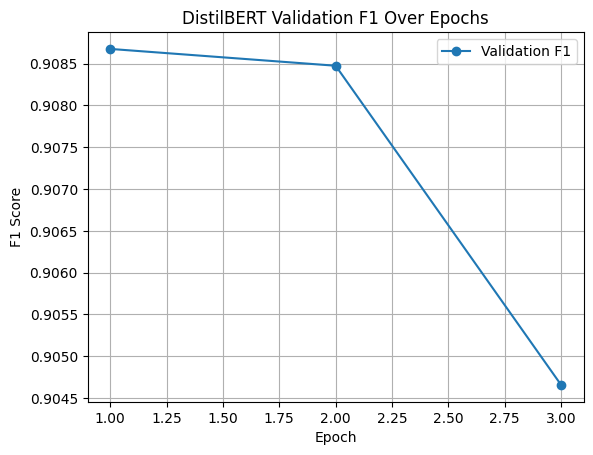

In [60]:
eval_metrics = history.dropna(subset=["eval_f1"]) # Dataframe of just eval_f1 rows

# Plot the DataFrame
plt.plot(eval_metrics["epoch"], eval_metrics["eval_f1"], marker="o", label="Validation F1")

# Label the Axis and provide Title
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("DistilBERT Validation F1 Over Epochs")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

# Model Evaluation

In [61]:
validation_results = trainer.evaluate(tokenized_sst2["validation"])

clean_test_results = trainer.evaluate(tokenized_sst2["test"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [62]:
results = pd.DataFrame([
    {
        "Data": "Validation",
        "Loss": validation_results["eval_loss"],
        "Accuracy": validation_results["eval_accuracy"],
        "Precision": validation_results["eval_precision"],
        "Recall": validation_results["eval_recall"],
        "F1": validation_results["eval_f1"]
    },
    {
        "Data": "Test",
        "Loss": clean_test_results["eval_loss"],
        "Accuracy": clean_test_results["eval_accuracy"],
        "Precision": clean_test_results["eval_precision"],
        "Recall": clean_test_results["eval_recall"],
        "F1": clean_test_results["eval_f1"]
    }
])

print(results.to_string(index = False))

      Data     Loss  Accuracy  Precision   Recall       F1
Validation 0.541602  0.908257   0.921296 0.896396 0.908676
      Test 0.326925  0.945805   0.962503 0.939446 0.950835


# Save Baseline Results

In [63]:
results.to_csv("distilbert_sst2_clean.csv", index = False)

# Creating OCR Noise Substitutions

https://communityhistoryarchives.com/100-common-ocr-letter-misinterpretations/
picked some most common letters and numbers

In [64]:
ocr_confusions = {
    "a": ["o", "e"],
    "b": ["o", "h"],
    "c": ["e", "o", "0"],
    "d": ["cl", "a", "o", "3", "8"],
    "e": ["c", "a", "o", "3", "8"],
    "f": ["i", "t", "l", "1", "|"],
    "g": ["q", "B", "8", "9", "y"],
    "h": ["n", "m", "b", "ln"],
    "i": ["l", "1", "|"],
    "j": ["i", "t", "1"],
    "k": ["h", "x", "b", "|<"],
    "l": ["1", "j", "I", "|"],
    "m": ["rn", "nn", "rr", "^^", "w", "iii"],
    "n": ["r", "ri", "h", "11"],
    "o": ["0", "c", "e", "*", "$", "@"],
    "p": ["f", "b", "o", "a", "9"],
    "q": ["g", "o", "a", "cl", "@"],
    "r": ["n", "v", "i"],
    "s": ["5", "z", "$", "8"],
    "t": ["f", "+", "l"],
    "u": ["y", "n", "v"],
    "v": ["u", "y", "\\/"],
    "w": ["vv", "m", "uu"],
    "x": ["k", "+", "><"],
    "y": ["v", "g", "j", "u", "7"],
    "z": ["2", "s", ">"]
}

# Creating OCR Noisy Sentences

`add_ocr_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds noise OCR style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [65]:
def add_ocr_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    noisy_sentence = []
    

    for character in sentence:
        character = character.lower()

        # If the character is in the ocr dictionary.
        # Then using random capped at noise level, determine a potential exchange
        if character in ocr_confusions and r.random() < noise_level:
            noisy_character = r.choice(ocr_confusions[character])
            noisy_sentence.append(noisy_character)
        else:
            noisy_sentence.append(character)

    # Join list back to complete sentence
    return "".join(noisy_sentence)

## Testing add_ocr_noise Function

In [77]:
# Test add_oct_noise function
sample_sentence = sst2["test"][3]["sentence"]

print("Original:")
print(sample_sentence)

print("\nNoisy Level 0.1:")
print(add_ocr_noise(sample_sentence, noise_level=0.1))

print("\nNoisy Level 0.3:")
print(add_ocr_noise(sample_sentence, noise_level=0.3))

print("\nNoisy Level 0.5:")
print(add_ocr_noise(sample_sentence, noise_level=0.5))

Original:
director rob marshall went out gunning to make a great one .

Noisy Level 0.1:
director rob manshall went out qunning to make a groat one .

Noisy Level 0.3:
dir3ct$r ioo maizhajl wcrit out gunhirig fo make e gnea+ ono .

Noisy Level 0.5:
d|vect$n ioo merzhajl wcrit eul gynriinq lo mabe o Br3el 0ha .


# Creating Noisy Dataset 

`create_noisy_dataset` function:

- Takes:
  - `dataset`: Dataset of sentences and labels to have noise applied to
  - `noise_function`: Function representing some type of noise application function
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10% 

- Returns:
  - `noisy_dataset`: Dataset of sentneces and labels that have had a specific level of noise applied


This function takes a dataset, a noise application function e.g. OCR and the level of noise e.g. 10% and returns the dataset with unchanged labels but with now noisy sentences

`apply_noise` function:

- Takes:
  - `dataset_row`: Single dataset row to have noise applied to

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added 


This function takes a row from a dataset and applies a provided noise function to that sentence and then returns it.

In [75]:
def create_noisy_dataset(dataset, noise_function, noise_level):

    
    # Function to apply noise depending on noise_function given
    def apply_noise(dataset_row):
        noisy_sentence = noise_function(dataset_row["sentence"], noise_level)

        return {"sentence": noisy_sentence} # Reokaces original with noisy in dataset row


    noisy_dataset = dataset.map(apply_noise) # Apply apply_noise to every row in dataset

    return noisy_dataset

## Testing create_noisy_dataset Function

In [74]:
# Create noisy dataset using ocr noise and noise level of 0.2
noisy_test_dataset = create_noisy_dataset(sst2["test"], add_ocr_noise, 0.2)

In [76]:
# Test to see if it creating noisy database function worked
i = 3
print("Original:")
print(sst2["test"][i]["sentence"], sst2["test"][i]["label"])

print("\nNoisy:")
print(noisy_test_dataset[i]["sentence"], noisy_test_dataset[i]["label"])

Original:
director rob marshall went out gunning to make a great one . -1

Noisy:
directoi r@b nnarshall vvenf ont gunning to mabe a gr8at 0ne . -1
